In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("../data/Iris.csv", sep=";")

Silhouette Score: 0.453


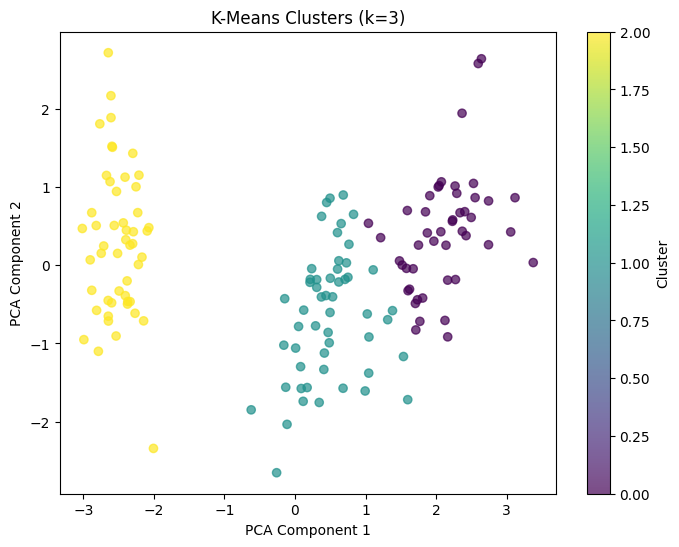

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Prepare data
X = df.copy()

# Optional but recommended for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit KMeans (3 clusters)
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df["Cluster"] = clusters

# Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)

print(f"Silhouette Score: {sil_score:.3f}")

# The figure
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(scatter, label="Cluster")
plt.title("K-Means Clusters (k=3)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [6]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: {score:.3f}")

k=2: 0.571
k=3: 0.453
k=4: 0.409
k=5: 0.327
k=6: 0.332
k=7: 0.343
k=8: 0.322
k=9: 0.331
k=10: 0.321
